# Exercise: Building RNNs for Sequence Prediction
## AIAT 122 - Deep Learning

## Learning Objectives

- Implement RNN from scratch
- Apply RNN to time series prediction
- Compare vanilla RNN vs LSTM
- Understand vanishing gradient problem

## Real-World Context

You're building a stock price prediction system for a fintech company.

## 📥 Inputs & 📤 Outputs | المدخلات والمخرجات

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


In [1]:
%pip install torch numpy pandas matplotlib -q

import torch
import torch.nn as nn
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt

print('✅ Setup complete!')

Note: you may need to restart the kernel to use updated packages.


✅ Setup complete!


## Task 1: Generate Synthetic Time Series (15 points)

Create a synthetic stock price dataset with trend and seasonality.

In [2]:
# TODO: Generate synthetic time series data
# Hint: Use sine wave + trend + noise
def generate_stock_data(n=100):
    t = np.linspace(0, 4 * np.pi, n)
    x = np.sin(t) + 0.1 * t + 0.1 * np.random.randn(n)
    return torch.FloatTensor(x).reshape(-1, 1)


## Task 2: Implement Simple RNN (25 points)

Build a simple RNN model using PyTorch.

In [3]:
# TODO: Implement SimpleRNN class
class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=8, output_size=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        h, _ = self.rnn(x)
        return self.fc(h)



## Task 3: Train RNN (30 points)

Train the RNN on stock data and evaluate performance.

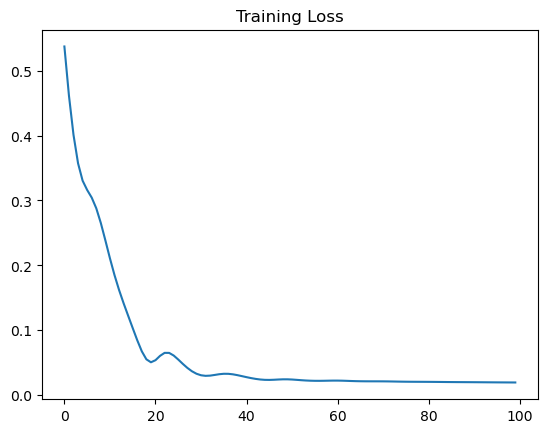

In [4]:
# TODO: Implement training loop
def train_rnn(model, data, epochs=100):
    losses = []
    opt = torch.optim.Adam(model.parameters(), lr=1e-2)
    X = data[:-1]
    y = data[1:]
    for _ in range(epochs):
        opt.zero_grad()
        out = model(X.unsqueeze(0))
        loss = nn.functional.mse_loss(out.squeeze(0), y)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses

# Train
data = generate_stock_data()
model = SimpleRNN()
losses = train_rnn(model, data)
plt.plot(losses)
plt.title('Training Loss')
plt.show()

## Task 4: Compare with LSTM (30 points)

Implement LSTM and compare with vanilla RNN.

In [5]:
# TODO: Implement LSTM model
class LSTMModel(nn.Module):
    pass
 


## Submission

**Total: 100 points**

Submit completed notebook with:
1. All implementations
2. Training plots
3. Comparison analysis (2-3 sentences)

**Real-World Application**: Stock prediction, weather forecasting, sales forecasting